Performing graphical visualizations on the cleaned dataset to understand the data distribution clearly

In [56]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(r'D:\E-Commerce_dynamic_system\src')

In [57]:
df=pd.read_csv(r'D:\E-Commerce_dynamic_system\data\processed\cleaned_products.csv',index_col=0)

In [58]:
from feature_engineering import engineer_all_features
df=engineer_all_features(df)

Univariate Analysis-Analysis on single column

In [59]:
df

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,listed_price,is_best_seller,is_sponsored,is_couponed,sustainability_badges,...,discounted_amount,discount_pct,value_score,demand_score,estimated_revenue,price_category,revenue_leakage_pct,premium_price_flag,price_vs_avg,review_credibility
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,0,1,0,0,...,69.32,43.597484,0.051293,0.0030,26904.0,Mid-range,43.597484,0,0.532177,27.276110
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,0,1,0,1,...,6.00,37.523452,0.430430,0.0600,59940.0,Budget,37.523452,0,0.059282,33.570544
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,0,1,0,1,...,35.00,10.028653,0.014650,0.0200,628000.0,Premium,10.028653,0,1.863333,36.897778
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,77.00,56.99,1,0,0,1,...,-20.01,-35.111423,0.059740,0.1000,770000.0,Mid-range,0.000000,1,0.456932,48.244887
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,77.00,56.99,0,0,0,1,...,-20.01,-35.111423,0.062338,0.1000,770000.0,Mid-range,0.000000,1,0.456932,49.318424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1.0,100.0,195.99,56.99,0,0,0,1,...,-139.00,-243.902439,0.025512,0.0010,19599.0,Premium,0.000000,1,1.163040,3.465736
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20.0,200.0,89.99,56.99,0,0,0,1,...,-33.00,-57.904896,0.046672,0.0020,17998.0,Mid-range,0.000000,1,0.534017,12.786994
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57.0,50.0,899.99,56.99,0,0,0,1,...,-843.00,-1479.206878,0.004778,0.0005,44999.5,Premium,0.000000,1,5.340704,17.459905
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102.0,500.0,10.39,15.98,0,0,0,1,...,5.59,34.981227,0.452358,0.0050,5195.0,Budget,34.981227,0,0.061656,41.680881


Price Distribution Analysis using histogram

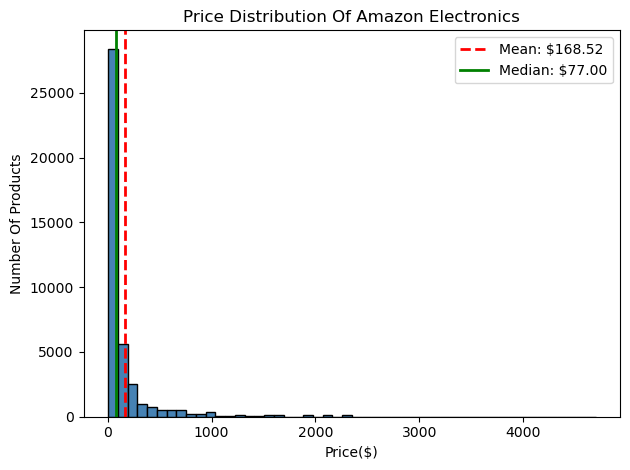

<Figure size 640x480 with 0 Axes>

In [60]:
plt.hist(df['current/discounted_price'],bins=50,color='steelblue',edgecolor='black')
mean_price = df['current/discounted_price'].mean()
median_price = df['current/discounted_price'].median()
# Mean line
plt.axvline(mean_price,color='red', linestyle='--',linewidth=2,label=f'Mean: ${mean_price:.2f}')
# Median line
plt.axvline(median_price,color='green',linestyle='-',linewidth=2,label=f'Median: ${median_price:.2f}')
plt.title("Price Distribution Of Amazon Electronics")
plt.xlabel("Price($)")
plt.ylabel("Number Of Products")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(r'D:\E-Commerce_dynamic_system\outputs\charts\price_distribution.png',
            dpi=300, bbox_inches='tight')

Rating Distribution

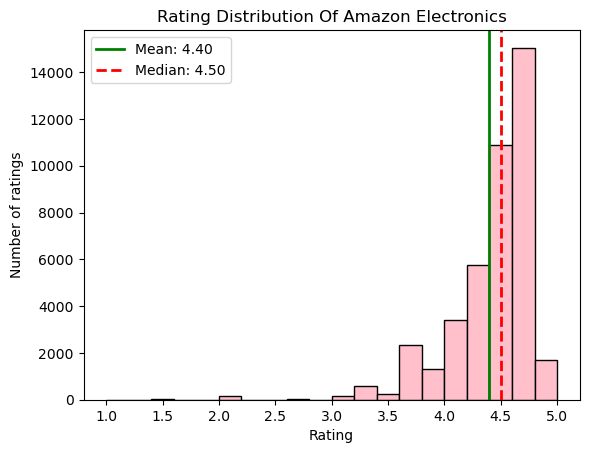

In [61]:

plt.hist(df['rating'],bins=20,color='pink',edgecolor='black')
mean_rating=df['rating'].mean()
median_rating=df['rating'].median()
plt.axvline(mean_rating,linestyle='-',linewidth=2,color='green',label=f'Mean: {mean_rating:.2f}')
plt.axvline(median_rating,linestyle='--',linewidth=2,color='red',label=f'Median: {median_rating:.2f}')
plt.title("Rating Distribution Of Amazon Electronics")
plt.xlabel("Rating")
plt.ylabel("Number of ratings")
plt.savefig(r'D:\E-Commerce_dynamic_system\outputs\charts\rating_distribution.png',
            dpi=300, bbox_inches='tight')
plt.legend()

Discount Percentage Distribution

In [62]:
df.columns

Index(['title', 'rating', 'number_of_reviews', 'bought_in_last_month',
       'current/discounted_price', 'listed_price', 'is_best_seller',
       'is_sponsored', 'is_couponed', 'sustainability_badges', 'collected_at',
       'discounted_amount', 'discount_pct', 'value_score', 'demand_score',
       'estimated_revenue', 'price_category', 'revenue_leakage_pct',
       'premium_price_flag', 'price_vs_avg', 'review_credibility'],
      dtype='object')

In [63]:
df.loc[df['discount_pct']<0,['discounted_amount','discount_pct','current/discounted_price']].head(20)

,discounted_amount,discount_pct,current/discounted_price
3,-20.01,-35.111423,77.00
4,-20.01,-35.111423,77.00
5,-20.01,-35.111423,77.00
6,-20.01,-35.111423,77.00
7,-20.01,-35.111423,77.00
9,-20.01,-35.111423,77.00
11,-20.01,-35.111423,77.00
13,-193.00,-338.655905,249.99
14,-12.96,-22.740832,69.95
15,-20.01,-35.111423,77.00


In [64]:
(df['discount_pct']<0).sum()

23654

In [65]:
(df['discount_pct']<0).mean()*100

56.790953398477825

In [66]:
df[['listed_price', 'current/discounted_price']].describe()

,listed_price,current/discounted_price
count,41651.000000,41651.000000
mean,75.432252,168.515247
std,87.715638,316.766992
min,4.950000,2.490000
25%,56.990000,34.990000
50%,56.990000,77.000000
75%,56.990000,129.990000
max,999.990000,4699.000000


In [67]:
(df['listed_price'] > df['current/discounted_price']).mean() * 100

43.20424479604331

Text(0, 0.5, 'Number of Products')

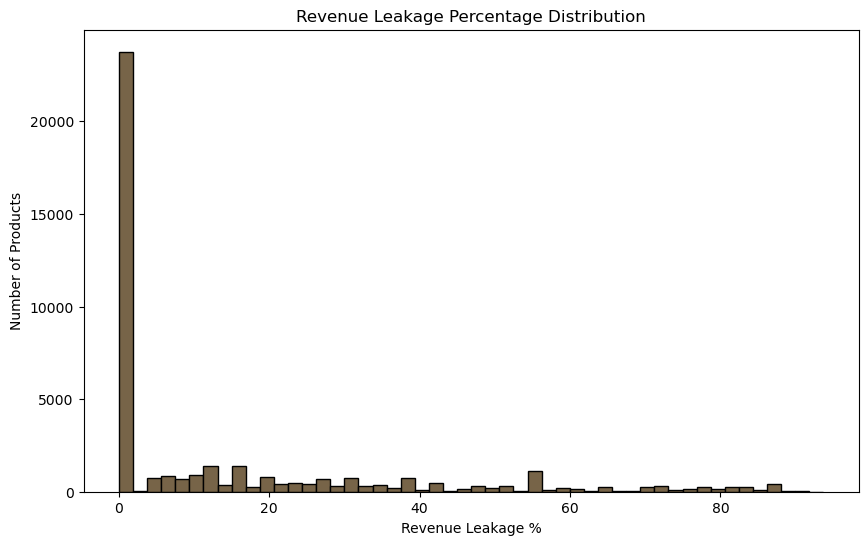

In [70]:
plt.figure(figsize=(10,6))
plt.hist(df['revenue_leakage_pct'],bins=50,color="#776448",edgecolor='black')
plt.title('Revenue Leakage Percentage Distribution')
plt.xlabel('Revenue Leakage %')
plt.ylabel('Number of Products')

Price category piechart,to visualize the proportions of categories always use value_counts() which creates pandas series where counts.values → the actual numeric counts (how many times each category appears).
counts.index → the labels (the category names themselves).

([<matplotlib.patches.Wedge at 0x27a3bc81a30>,
 [Text(-0.23079355062010642, 1.075515846927494, 'Mid-range'),
  Text(-0.3475951782378842, -1.0436367146022478, 'Premium'),
  Text(0.9474773371359269, -0.5588261765646034, 'Budget')],
 [Text(-0.12588739124733075, 0.5866450074149966, '56.7%'),
  Text(-0.18959736994793683, -0.5692563897830442, '26.3%'),
  Text(0.5168058202559601, -0.30481427812614725, '17.0%')])

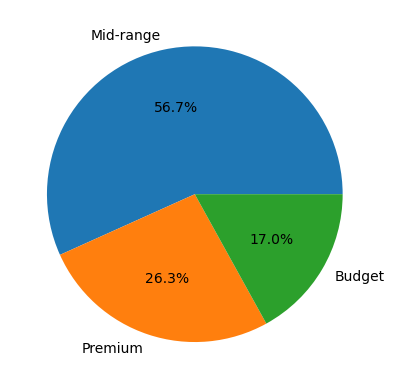

In [73]:
counts=df['price_category'].value_counts()
plt.pie(counts.values,labels=counts.index,autopct="%1.1f%%")